## 1. Multi-class and Multi-Label Classification Using Support Vector Machines

Import packages

In [1]:
from __future__ import annotations
try:
    import warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    from xgboost import XGBClassifier
    from collections import defaultdict
    from sklearn.svm import SVC
    from pathlib import Path
    from dataclasses import dataclass
    from typing import Tuple, Dict
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer 
    from sklearn.preprocessing import StandardScaler
    from imblearn.over_sampling import SMOTE
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.pipeline import Pipeline
    from sklearn.svm import SVC, LinearSVC
    from sklearn.cluster import KMeans
    from kneed import KneeLocator
    from sklearn.decomposition import PCA
    from scipy.spatial.distance import squareform
    from scipy.cluster.hierarchy import dendrogram, linkage
    from sklearn.model_selection import (
        KFold, StratifiedKFold, GridSearchCV, cross_val_score, train_test_split
    )
    from sklearn.metrics import (
        silhouette_score, classification_report, precision_recall_curve, accuracy_score)
    print("Imported all packages successfully.!")
except Exception as e:
    print(f"Error importing the following packages: {e}")
    print("Installing the non-present packages!!..")
    %pip install -r "requirements.txt"
    warnings.filterwarnings("ignore")
    print("Installation Successfull")

Imported all packages successfully.!


### (a) Download the Anuran Calls (MFCCs) Data Set

In [2]:
PATH = Path("../data/Frogs_MFCCs.csv")
df_full: pd.DataFrame = []
columns = []
try:
    if PATH.exists:
        df_full = pd.read_csv(PATH)
        columns = df_full
        print(f"\n {df_full.shape}")
        print(f"\n {df_full.head(3)}")
        print(f"\n Features and Class name cols: {df_full.columns}")
    else:
        print("Path may not exist or something is wrong, please read the exception!")
except Exception as e:
    print(f"Error Loading Data: {e}")


 (7195, 26)

    MFCCs_ 1  MFCCs_ 2  MFCCs_ 3  MFCCs_ 4  MFCCs_ 5  MFCCs_ 6  MFCCs_ 7  \
0       1.0  0.152936 -0.105586  0.200722  0.317201  0.260764  0.100945   
1       1.0  0.171534 -0.098975  0.268425  0.338672  0.268353  0.060835   
2       1.0  0.152317 -0.082973  0.287128  0.276014  0.189867  0.008714   

   MFCCs_ 8  MFCCs_ 9  MFCCs_10  ...  MFCCs_17  MFCCs_18  MFCCs_19  MFCCs_20  \
0 -0.150063 -0.171128  0.124676  ... -0.108351 -0.077623 -0.009568  0.057684   
1 -0.222475 -0.207693  0.170883  ... -0.090974 -0.056510 -0.035303  0.020140   
2 -0.242234 -0.219153  0.232538  ... -0.050691 -0.023590 -0.066722 -0.025083   

   MFCCs_21  MFCCs_22           Family      Genus         Species  RecordID  
0  0.118680  0.014038  Leptodactylidae  Adenomera  AdenomeraAndre         1  
1  0.082263  0.029056  Leptodactylidae  Adenomera  AdenomeraAndre         1  
2  0.099108  0.077162  Leptodactylidae  Adenomera  AdenomeraAndre         1  

[3 rows x 26 columns]

 Features and Class name co

In [3]:
def df_info(df: pd.DataFrame) -> None:
    print(f"\n {df.shape}")
    print(f"\n Columns:--> {df.columns}")
    print(f"\n {df.head(1)}")
    print(f"\n {df.dtypes}")

In [4]:
def prepare_data(df: pd.DataFrame) -> List[pd.DataFrame]:
    """
    We Randomly Choose 70% as the Training Data and the rest as Test Data
    """
    try:
        train_df, test_df = train_test_split(df, train_size=0.7, shuffle=True, random_state=42, stratify=df["Family"])
    
        return train_df, test_df
    except Exception as e:
        print(f"Error Splitting the DataFrame: {e}")
        return []

In [5]:
train_df, test_df = prepare_data(df_full)

In [6]:
"""As per given dataset"""
label_cols = ["Family", "Species", "Genus"]
train_df = train_df.drop(columns=["RecordID"])
test_df = test_df.drop(columns=["RecordID"])
X_train = train_df.drop(columns=label_cols).copy()
y_train = train_df[label_cols].copy()
X_test = test_df.drop(columns=label_cols).copy()
y_test = test_df[label_cols].copy()
df_info(X_train)
df_info(y_train)
df_info(X_test)
df_info(y_test)


 (5036, 22)

 Columns:--> Index(['MFCCs_ 1', 'MFCCs_ 2', 'MFCCs_ 3', 'MFCCs_ 4', 'MFCCs_ 5', 'MFCCs_ 6',
       'MFCCs_ 7', 'MFCCs_ 8', 'MFCCs_ 9', 'MFCCs_10', 'MFCCs_11', 'MFCCs_12',
       'MFCCs_13', 'MFCCs_14', 'MFCCs_15', 'MFCCs_16', 'MFCCs_17', 'MFCCs_18',
       'MFCCs_19', 'MFCCs_20', 'MFCCs_21', 'MFCCs_22'],
      dtype='object')

       MFCCs_ 1  MFCCs_ 2  MFCCs_ 3  MFCCs_ 4  MFCCs_ 5  MFCCs_ 6  MFCCs_ 7  \
1128       1.0  0.464278   0.35561  0.471496  0.204044  0.107364  0.176108   

      MFCCs_ 8  MFCCs_ 9  MFCCs_10  ...  MFCCs_13  MFCCs_14  MFCCs_15  \
1128  0.013638 -0.154969 -0.009043  ... -0.322604   0.06849   0.12614   

      MFCCs_16  MFCCs_17  MFCCs_18  MFCCs_19  MFCCs_20  MFCCs_21  MFCCs_22  
1128 -0.153162 -0.156243  0.034949 -0.008984  -0.12156 -0.085381 -0.017288  

[1 rows x 22 columns]

 MFCCs_ 1    float64
MFCCs_ 2    float64
MFCCs_ 3    float64
MFCCs_ 4    float64
MFCCs_ 5    float64
MFCCs_ 6    float64
MFCCs_ 7    float64
MFCCs_ 8    float64
MFCCs_ 9    f

### (b) Train a classifier for each label

#### (i) Research

<h5>
<div>
1. Exact Match: -> <br/>
Definition: Exact Match is the strictest evaluation metric for multi‑label classification. <br/>

For each sample, Exact Match = 1 only if the predicted label set is identical to the true label set. <br/>

Exact Match = $\frac{1}{N} \Sigma_{i=1}^{N} 1(y_{i} = \hat{y}_{i})$
</div>

<div>
2. Hamming Score: -> <br/>
Definition: Measures the fraction of misclassified labels (per label, averaged over samples). <br/>

Much more forgiving than Exact Match.<br/>

Evaluates each label independently.<br/>

If a sample has 4 labels and the model gets 3 correct → Hamming Score = 0.75. <br/>

Hamming Score  = 1 - Hamming Loss

Hamming Loss = $\frac{1}{N.L} \Sigma_{i=1}^{N} \Sigma_{j=1}^{L} 1(y_{ij}\neq \hat{y}_{ij})$

</div>
</h5>

In [7]:
def hamming_loss(y_true, y_pred):
    """Count mismatches and divide them by total number of samples"""
    return round(np.mean(y_true != y_pred), 4)
    
def hamming_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    a = []
    for i in range(y_true.shape[0]):
        set_t = set(np.where(np.atleast_1d(y_true[i]))[0])
        set_p = set(np.where(np.atleast_1d(y_pred[i]))[0])
        if len(set_t) == 0 and len(set_p) == 0:
            temp_ = 1.0
        else:
            temp_ = len(set_t.intersection(set_p)) / float(len(set_t.union(set_p)))
        a.append(temp_)
    return round(np.mean(a), 4)

def exact_match(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    em = np.mean(np.all(y_true == y_pred, axis=1))
    return round(em, 4)

#### (ii) Train a SVM for each of the labels

In [8]:
def rbf_search_svm(X_train, y_train, X_test, y_test, label):
    params={
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.1, 1, 10]
    }
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    svm = SVC(kernel='rbf', decision_function_shape='ovr')
    grid = GridSearchCV(estimator=svm,
                        param_grid=params,
                        cv=cv,
                        scoring="f1_weighted",
                        n_jobs=-1)

    grid.fit(X_train, y_train[label])
    print(f"Best Parameters for label: {label}:--> {grid.best_params_}")
    
    y_pred = grid.predict(X_test)
    print(f"\n Classification Report for Label: {label}:--> \n {classification_report(y_test[label], y_pred)}")
    
    return grid.best_estimator_

In [9]:
rbf_search_res = {}
for i in label_cols:
    rbf_search_res[i] = rbf_search_svm(X_train, y_train, X_test, y_test, i) 

Best Parameters for label: Family:--> {'C': 100, 'gamma': 1}

 Classification Report for Label: Family:--> 
                  precision    recall  f1-score   support

      Bufonidae       0.95      1.00      0.98        20
  Dendrobatidae       1.00      0.99      1.00       163
        Hylidae       0.99      0.99      0.99       650
Leptodactylidae       0.99      1.00      1.00      1326

       accuracy                           0.99      2159
      macro avg       0.98      0.99      0.99      2159
   weighted avg       0.99      0.99      0.99      2159

Best Parameters for label: Species:--> {'C': 100, 'gamma': 1}

 Classification Report for Label: Species:--> 
                         precision    recall  f1-score   support

        AdenomeraAndre       0.98      0.99      0.99       183
AdenomeraHylaedactylus       1.00      1.00      1.00      1052
    Ameeregatrivittata       1.00      0.99      0.99       163
            HylaMinuta       0.98      0.97      0.97        99


In [10]:
print("\n Performance on all labels (raw)")
y_true_all = np.column_stack([
    y_test[i].to_numpy() for i in label_cols
])

y_pred_all = np.column_stack([
    rbf_search_res[i].predict(X_test) for i in label_cols
])

h_loss = hamming_loss(y_true_all, y_pred_all)
h_score = hamming_score(y_true_all, y_pred_all)
em = exact_match(y_true_all, y_pred_all)
print(f"\n Hamming Loss: {h_loss}")
print(f"\n Hamming Score: {h_score}")
print(f"\n Exact Match: {em}")


 Performance on all labels (raw)

 Hamming Loss: 0.0073

 Hamming Score: 1.0

 Exact Match: 0.9889


#### (iii) Repeat 1(b)ii with L1-penalized SVMs

In [11]:
def svm_linear(X_train, y_train, X_test, y_test, label, sm=False):
    params={
        'C': [0.1, 1, 10, 100]
    }
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    svm = LinearSVC(penalty='l1', dual=False, max_iter=10000)
    grid = GridSearchCV(estimator=svm,
                        param_grid=params,
                        cv=cv,
                        scoring="f1_weighted",
                        n_jobs=-1)
    if sm:
        grid.fit(X_train, y_train)
    else:
        grid.fit(X_train, y_train[label])
    print(f"Linear SVM Best Parameters for label: {label}:--> {grid.best_params_}")
    
    y_pred = grid.predict(X_test)
    if sm:
        print(f"\n Linear SVM Classification Report for Label: {label}:--> \n {classification_report(y_test[label], y_pred, zero_division=0)}")
    else:
        print(f"\n Linear SVM Classification Report for Label: {label}:--> \n {classification_report(y_test[label], y_pred)}")
    
    return grid.best_estimator_

In [12]:
svm_linear_res = {}
for l in label_cols:
    svm_linear_res[l] = svm_linear(X_train, y_train, X_test, y_test, l)

C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Linear SVM Best Parameters for label: Family:--> {'C': 100}

 Linear SVM Classification Report for Label: Family:--> 
                  precision    recall  f1-score   support

      Bufonidae       0.00      0.00      0.00        20
  Dendrobatidae       0.89      0.91      0.90       163
        Hylidae       0.92      0.92      0.92       650
Leptodactylidae       0.96      0.97      0.97      1326

       accuracy                           0.94      2159
      macro avg       0.69      0.70      0.70      2159
   weighted avg       0.94      0.94      0.94      2159



C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Linear SVM Best Parameters for label: Species:--> {'C': 100}

 Linear SVM Classification Report for Label: Species:--> 
                         precision    recall  f1-score   support

        AdenomeraAndre       0.94      0.97      0.96       183
AdenomeraHylaedactylus       0.99      1.00      0.99      1052
    Ameeregatrivittata       0.93      0.97      0.95       163
            HylaMinuta       0.94      0.76      0.84        99
  HypsiboasCinerascens       0.92      0.96      0.94       136
     HypsiboasCordobae       0.94      0.97      0.95       334
   LeptodactylusFuscus       1.00      0.98      0.99        91
 OsteocephalusOophagus       1.00      0.64      0.78        39
     Rhinellagranulosa       0.87      1.00      0.93        20
           ScinaxRuber       0.97      0.90      0.94        42

              accuracy                           0.97      2159
             macro avg       0.95      0.91      0.93      2159
          weighted avg       0.97      0.97  

C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [13]:
print("\n Linear SVM Performance on all labels (raw)")
y_pred_all_ = np.column_stack([
    svm_linear_res[i].predict(X_test) for i in label_cols
])

h_loss_ = hamming_loss(y_true_all, y_pred_all_)
h_score_ = hamming_score(y_true_all, y_pred_all_)
em_ = exact_match(y_true_all, y_pred_all_)
print(f"\n Hamming Loss: {h_loss_}")
print(f"\n Hamming Score: {h_score_}")
print(f"\n Exact Match: {em_}")


 Linear SVM Performance on all labels (raw)

 Hamming Loss: 0.0446

 Hamming Score: 1.0

 Exact Match: 0.9194


#### (iv) Repeat 1(b)iii by using SMOTE or any other method for imbalance

In [15]:
sm = SMOTE(random_state=42, sampling_strategy='auto')
svm_linear_smote = {}
for l in label_cols:
    X_train_, y_train_ = sm.fit_resample(X_train, y_train[l])
    print("Applied SMOTE successfully")
    svm_linear_smote[l] = svm_linear(X_train_, y_train_, X_test, y_test, l, sm=True)

print("\n Linear SVM with SMOTE Performance on all labels (raw)")
_y_pred_all_ = np.column_stack([
    svm_linear_smote[i].predict(X_test) for i in label_cols
])

_h_loss_ = hamming_loss(y_true_all, _y_pred_all_)
_h_score_ = hamming_score(y_true_all, _y_pred_all_)
_em_ = exact_match(y_true_all, _y_pred_all_)
print(f"\n Hamming Loss: {_h_loss_}")
print(f"\n Hamming Score: {_h_score_}")
print(f"\n Exact Match: {_em_}")

Applied SMOTE successfully


C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Linear SVM Best Parameters for label: Family:--> {'C': 10}

 Linear SVM Classification Report for Label: Family:--> 
                  precision    recall  f1-score   support

      Bufonidae       0.27      1.00      0.43        20
  Dendrobatidae       0.75      0.98      0.85       163
        Hylidae       0.93      0.87      0.90       650
Leptodactylidae       0.97      0.93      0.95      1326

       accuracy                           0.91      2159
      macro avg       0.73      0.94      0.78      2159
   weighted avg       0.94      0.91      0.92      2159

Applied SMOTE successfully


C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Linear SVM Best Parameters for label: Species:--> {'C': 100}

 Linear SVM Classification Report for Label: Species:--> 
                         precision    recall  f1-score   support

        AdenomeraAndre       0.96      0.95      0.95       183
AdenomeraHylaedactylus       0.99      0.99      0.99      1052
    Ameeregatrivittata       0.95      0.94      0.94       163
            HylaMinuta       0.87      0.92      0.89        99
  HypsiboasCinerascens       0.93      0.92      0.92       136
     HypsiboasCordobae       0.98      0.93      0.96       334
   LeptodactylusFuscus       0.97      0.98      0.97        91
 OsteocephalusOophagus       0.79      0.77      0.78        39
     Rhinellagranulosa       0.53      1.00      0.69        20
           ScinaxRuber       0.95      0.90      0.93        42

              accuracy                           0.96      2159
             macro avg       0.89      0.93      0.90      2159
          weighted avg       0.97      0.96  

C:\Users\athar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## 2. K-Means Clustering on a Multi-Class and Multi-Label Data Set

### (a) Use k-means clustering

In [16]:
df_ = df_full.drop(columns=["RecordID"]).copy()
y_ = df_[label_cols].copy()
X_ = df_.drop(columns=label_cols).copy()
k_results = []
sil_results = []
for k in range(1, 51):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_)
    k_results.append(kmeans.inertia_)
    if k > 1:
        sil_results.append(silhouette_score(X_, kmeans.labels_))


 OPtimal K by finding the elbow is: 10


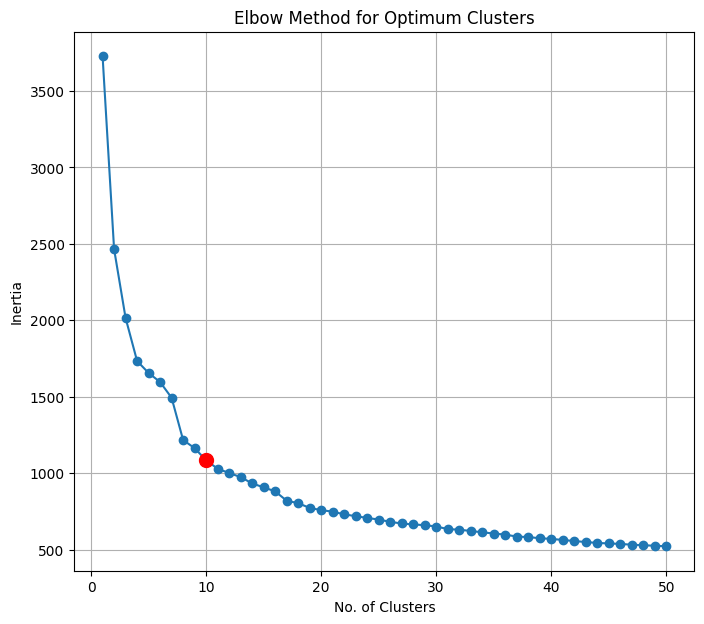

In [17]:
x_values = range(1, len(k_results) + 1)
optimal_k = KneeLocator(x_values, k_results, curve='convex', direction='decreasing')
plt.figure(figsize=(8, 7))
plt.plot(x_values, k_results, marker='o')
plt.plot(optimal_k.knee, optimal_k.knee_y, 'ro', markersize=10, label='Elbow Point')
print(f"\n OPtimal K by finding the elbow is: {optimal_k.knee}")
plt.title("Elbow Method for Optimum Clusters")
plt.xlabel("No. of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

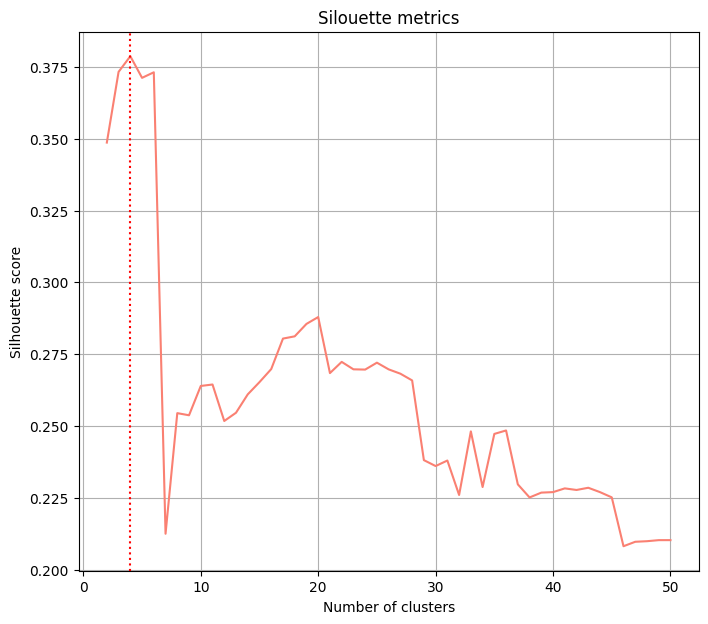

In [18]:
# Now lets also find the optimum clusters with silhoutte score
plt.figure(figsize=(8, 7))
plt.grid(True)
plt.plot(range(2, 51), sil_results, color = 'salmon')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silouette metrics')
plt.axvline(x = sil_results.index(max(sil_results))+2, linestyle = 'dotted', color = 'red') 
plt.show()

In [19]:
# Used Just for my reference (this was at the start initially)
for i in label_cols:
    print(f"\n {i} --> ")
    print(f"{df_full[i].unique()}")


 Family --> 
['Leptodactylidae' 'Dendrobatidae' 'Hylidae' 'Bufonidae']

 Species --> 
['AdenomeraAndre' 'Ameeregatrivittata' 'AdenomeraHylaedactylus'
 'HylaMinuta' 'HypsiboasCinerascens' 'HypsiboasCordobae'
 'LeptodactylusFuscus' 'OsteocephalusOophagus' 'Rhinellagranulosa'
 'ScinaxRuber']

 Genus --> 
['Adenomera' 'Ameerega' 'Dendropsophus' 'Hypsiboas' 'Leptodactylus'
 'Osteocephalus' 'Rhinella' 'Scinax']


### (b) Determine which family is the majority

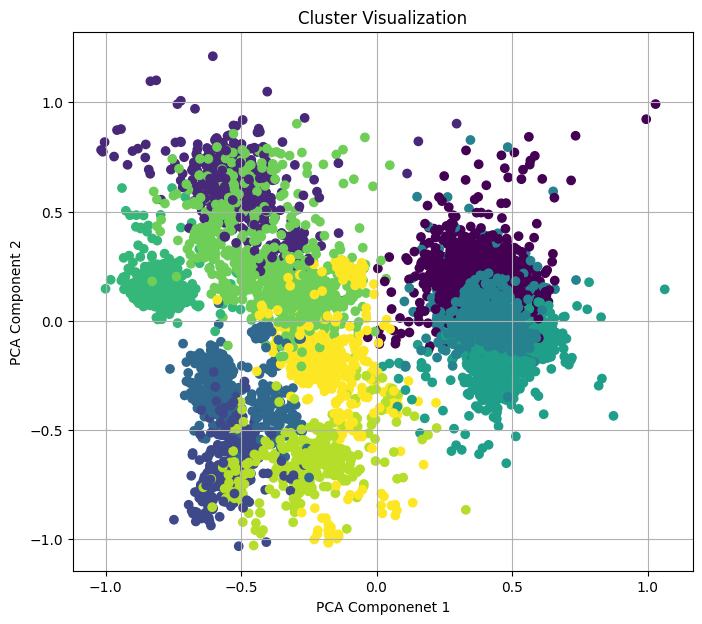

In [20]:
pca = PCA(n_components=2)
new_kmeans = KMeans(n_clusters=10, random_state=42) # I got k =10 as a result from the previous question
c = new_kmeans.fit_predict(X_)
X_pca = pca.fit_transform(X_)
plt.figure(figsize=(8, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=c, cmap='viridis')
plt.title("Cluster Visualization")
plt.xlabel("PCA Componenet 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

In [21]:
df_['cluster'] = c
cluster_res = {}
for i in range(10):
    sub = df_[df_['cluster'] == i]
    maj_fam = sub['Family'].value_counts().idxmax()
    maj_genus = sub['Genus'].value_counts().idxmax()
    maj_species = sub['Species'].value_counts().idxmax()
    cluster_res[i] = (maj_fam, maj_genus, maj_species)
print("\n Cluster ID  Major Family,   Major Genus,   Major Species")
for k, v in cluster_res.items():
    print(f"\n Cluster: {k}: {v}")


 Cluster ID  Major Family,   Major Genus,   Major Species

 Cluster: 0: ('Leptodactylidae', 'Adenomera', 'AdenomeraHylaedactylus')

 Cluster: 1: ('Hylidae', 'Hypsiboas', 'HypsiboasCinerascens')

 Cluster: 2: ('Leptodactylidae', 'Adenomera', 'AdenomeraAndre')

 Cluster: 3: ('Dendrobatidae', 'Ameerega', 'Ameeregatrivittata')

 Cluster: 4: ('Leptodactylidae', 'Adenomera', 'AdenomeraHylaedactylus')

 Cluster: 5: ('Leptodactylidae', 'Adenomera', 'AdenomeraHylaedactylus')

 Cluster: 6: ('Leptodactylidae', 'Adenomera', 'AdenomeraAndre')

 Cluster: 7: ('Hylidae', 'Hypsiboas', 'HypsiboasCordobae')

 Cluster: 8: ('Dendrobatidae', 'Ameerega', 'Ameeregatrivittata')

 Cluster: 9: ('Hylidae', 'Hypsiboas', 'HypsiboasCordobae')


### (c) Calculate the average Hamming distance, Hamming score, and Hamming loss

In [22]:
y_cluster = np.array([cluster_res[i] for i in c], dtype=object)
y_true_final = df_[label_cols].to_numpy()
_hl_ = hamming_loss(y_true_final, y_cluster)
_hs_ = hamming_score(y_true_final, y_cluster)
_em_ = exact_match(y_true_final, y_cluster)

print(f"\n The hamming Loss: {_hl_}")
print(f"\n The hamming Score: {_hs_}")
print(f"\n Exact Match: {_em_}")


 The hamming Loss: 0.6984

 The hamming Score: 1.0

 Exact Match: 0.0


## 3. ISLR 12.6.2

<p>
<div> 
    (a)
</div>
</p>

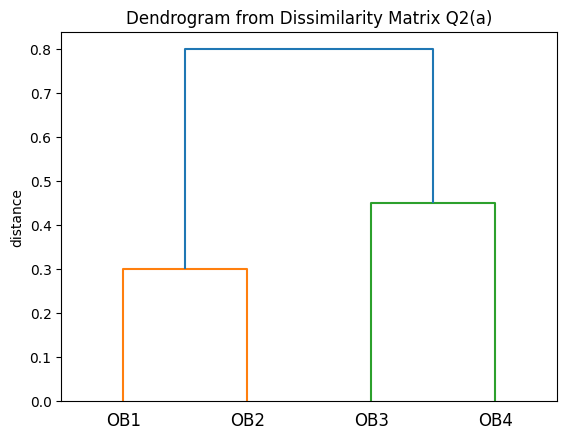

In [23]:
dis_matrix = np.array([
    [0, 0.3, 0.4, 0.7],
    [0.3, 0, 0.5, 0.8],
    [0.4, 0.5, 0, 0.45],
    [0.7, 0.8, 0.45, 0]
])

condensed = squareform(dis_matrix)
z = linkage(condensed, method='complete')

plt.plot(figsize=(8,6))
dendrogram(z, labels = ['OB1', 'OB2', 'OB3', 'OB4'])
plt.title("Dendrogram from Dissimilarity Matrix Q2(a)")
plt.ylabel("distance")
plt.show()

<p>
<div> 
    (b)
</div>
</p>

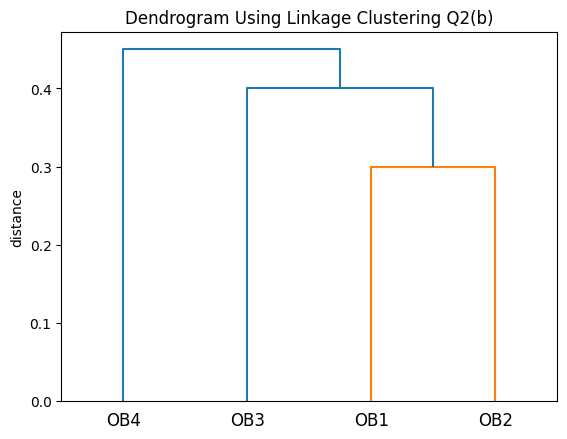

In [24]:
s = linkage(condensed, method='single')
plt.plot(figsize=(8,6))
dendrogram(s, labels = ['OB1', 'OB2', 'OB3', 'OB4'])
plt.title("Dendrogram Using Linkage Clustering Q2(b)")
plt.ylabel("distance")
plt.show()

<div>
<ul>
<li>
    First Merge is at 0.3 (OB1 & OB2)
</li> 
<li>
    Second Merge is at 0.4 (OB3 & Cluster)
</li>
<li>
    Final Merge is at 0.45 (OB4 & Cluster)
</li>
</ul>
</div>

<div>
<p>(c)</p>
<p>
So if we cut the dendrogram obtained in (a) in two clusters, one can find <br/>
OB1 & OB2 in one cluster and OB3 & OB4 in the second.
</p>
</div>

<div>
<p>(d)</p>
<p>
Now in case of (b) we will observe a different result. OB1 & OB2 will be in one cluster. <br/>
OB3 and OB4 will be individual entities which can be observed from the figure as they later merge with the cluster at 0.45 and 0.4 respectively.
</p>
</div>

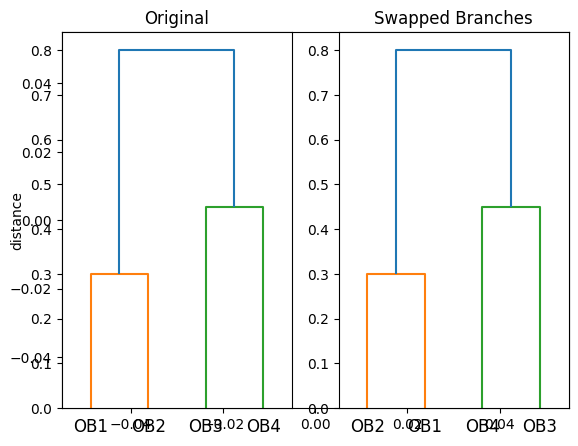

In [25]:
plt.plot(figsize=(10, 6))
plt.subplot(1,2,1)
dendrogram(z, labels = ['OB1', 'OB2', 'OB3', 'OB4'])
plt.title("Original")
plt.ylabel("distance")
plt.subplot(1, 2, 2)
dendrogram(z, labels = ['OB2', 'OB1', 'OB4', 'OB3']) 
plt.title("Swapped Branches")

plt.tight_layout()
plt.show()